**Clone Ultralytics**

This notebook creates a YOLO11n-seg + ECA Attention experiment. It follows the same workflow as the SimAM/CA notebooks: clone → patch module → create YAML → test build → train → val → predict → export.

In [1]:
from pathlib import Path
import subprocess
import sys
import os

os.chdir("/content")

ULTRA_DIR = Path("/content/ultralytics")

if not ULTRA_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/ultralytics/ultralytics.git", str(ULTRA_DIR)],
        check=True
    )
else:
    print("Ultralytics already exists:", ULTRA_DIR)

print("Done:", ULTRA_DIR)

Done: /content/ultralytics


**Add Efficient Channel Attention (ECA)**

This cell patches local Ultralytics source code to register `ECAAttention` as a YAML module. ECA is inserted before the Segment head for P3, P4, and P5 features.

In [2]:
from pathlib import Path
import re

ULTRA_DIR = Path("/content/ultralytics")
conv_py = ULTRA_DIR / "ultralytics/nn/modules/conv.py"
init_py = ULTRA_DIR / "ultralytics/nn/modules/__init__.py"
tasks_py = ULTRA_DIR / "ultralytics/nn/tasks.py"

# Backup before patch
for p in [conv_py, init_py, tasks_py]:
    backup = p.with_suffix(p.suffix + ".bak_eca_fixed")
    if not backup.exists():
        backup.write_text(p.read_text())
        print("Backup created:", backup)

eca_code = r'''

class ECAAttention(nn.Module):
    """
    ECA-Net: Efficient Channel Attention.

    Args:
        c1 (int): input channels.
        k_size (int): kernel size for 1D channel convolution.
    """

    def __init__(self, c1, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            1,
            1,
            kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W]
        y = self.avg_pool(x)                         # [B, C, 1, 1]
        y = y.squeeze(-1).transpose(-1, -2)          # [B, 1, C]
        y = self.conv(y)                             # [B, 1, C]
        y = self.sigmoid(y).transpose(-1, -2).unsqueeze(-1)  # [B, C, 1, 1]
        return x * y.expand_as(x)
'''

simam_code = r'''

class SimAM(nn.Module):
    """
    SimAM: Simple, Parameter-Free Attention Module.
    Compatible with Ultralytics YAML parsing.
    """

    def __init__(self, c1=None, e_lambda=1e-4):
        super().__init__()
        self.e_lambda = e_lambda
        self.activation = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        n = h * w - 1

        if n <= 0:
            return x

        x_minus_mu_square = (x - x.mean(dim=[2, 3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (
            4 * (x_minus_mu_square.sum(dim=[2, 3], keepdim=True) / n + self.e_lambda)
        ) + 0.5

        return x * self.activation(y)
'''


# =========================================================
# 1. Patch conv.py
# =========================================================
text = conv_py.read_text()

# Ensure torch import exists
if "import torch\n" not in text:
    if "import math\n" in text:
        text = text.replace("import math\n", "import math\nimport torch\n")
    else:
        text = "import torch\n" + text

# Add ECAAttention / SimAM to conv.py __all__
if '"ECAAttention",' not in text:
    if '"Concat",' in text:
        text = text.replace('"Concat",', '"Concat",\n    "ECAAttention",')
    else:
        print("WARNING: Could not find __all__ insertion point for ECAAttention in conv.py")

if '"SimAM",' not in text:
    if '"Concat",' in text:
        text = text.replace('"Concat",', '"Concat",\n    "SimAM",')
    else:
        print("WARNING: Could not find __all__ insertion point for SimAM in conv.py")

# Add classes
if "class ECAAttention(nn.Module):" not in text:
    text = text.rstrip() + eca_code + "\n"

if "class SimAM(nn.Module):" not in text:
    text = text.rstrip() + simam_code + "\n"

conv_py.write_text(text)
print("Patched conv.py with ECAAttention + SimAM")


# =========================================================
# 2. Patch __init__.py
# =========================================================
text = init_py.read_text()

# Add to from .conv import (...)
if "from .conv import (" in text:
    conv_import_block = text.split("from .conv import (", 1)[1].split(")", 1)[0]

    if "ECAAttention" not in conv_import_block:
        if "    Concat," in text:
            text = text.replace("    Concat,", "    Concat,\n    ECAAttention,")
        else:
            text = text.replace("from .conv import (", "from .conv import (\n    ECAAttention,")

    # Re-read block after replacement
    conv_import_block = text.split("from .conv import (", 1)[1].split(")", 1)[0]

    if "SimAM" not in conv_import_block:
        if "    Concat," in text:
            text = text.replace("    Concat,", "    Concat,\n    SimAM,")
        else:
            text = text.replace("from .conv import (", "from .conv import (\n    SimAM,")
else:
    if "from .conv import ECAAttention" not in text:
        text += "\nfrom .conv import ECAAttention\n"
    if "from .conv import SimAM" not in text:
        text += "\nfrom .conv import SimAM\n"

# Add to __all__
if "__all__" in text:
    all_block = text.split("__all__", 1)[1]

    if '"ECAAttention"' not in all_block:
        if '"Concat",' in text:
            text = text.replace('"Concat",', '"Concat",\n    "ECAAttention",')
        else:
            print("WARNING: Could not find __all__ insertion point for ECAAttention in __init__.py")

    all_block = text.split("__all__", 1)[1]

    if '"SimAM"' not in all_block:
        if '"Concat",' in text:
            text = text.replace('"Concat",', '"Concat",\n    "SimAM",')
        else:
            print("WARNING: Could not find __all__ insertion point for SimAM in __init__.py")

init_py.write_text(text)
print("Patched __init__.py with ECAAttention + SimAM")


# =========================================================
# 3. Patch tasks.py
# =========================================================
text = tasks_py.read_text()

# Add ECAAttention / SimAM to import block
if "from ultralytics.nn.modules import (" in text:
    modules_import_block = text.split("from ultralytics.nn.modules import (", 1)[1].split(")", 1)[0]

    if "ECAAttention" not in modules_import_block:
        if "    Concat," in text:
            text = text.replace("    Concat,", "    Concat,\n    ECAAttention,")
        else:
            text = text.replace(
                "from ultralytics.nn.modules import (",
                "from ultralytics.nn.modules import (\n    ECAAttention,"
            )

    modules_import_block = text.split("from ultralytics.nn.modules import (", 1)[1].split(")", 1)[0]

    if "SimAM" not in modules_import_block:
        if "    Concat," in text:
            text = text.replace("    Concat,", "    Concat,\n    SimAM,")
        else:
            text = text.replace(
                "from ultralytics.nn.modules import (",
                "from ultralytics.nn.modules import (\n    SimAM,"
            )

# Remove ECAAttention from base_modules if it was inserted before
base_start = text.find("base_modules = frozenset")
repeat_start = text.find("repeat_modules = frozenset", base_start)

if base_start != -1 and repeat_start != -1:
    base_block = text[base_start:repeat_start]
    if "ECAAttention" in base_block:
        base_block_new = base_block.replace("            ECAAttention,\n", "")
        base_block_new = base_block_new.replace("        ECAAttention,\n", "")
        base_block_new = base_block_new.replace("ECAAttention,\n", "")
        text = text[:base_start] + base_block_new + text[repeat_start:]
        print("Removed ECAAttention from base_modules")

# Add custom parse branch for ECAAttention before SimAM branch
if "elif m is ECAAttention:" not in text:
    simam_anchor = """elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]"""

    eca_branch = """elif m is ECAAttention:
            c2 = ch[f]
            # YAML supported:
            #   - [16, 1, ECAAttention, [3]]
            #   - [16, 1, ECAAttention, [256, 3]]
            # In both cases, input channel is inferred from ch[f].
            if len(args) >= 2:
                k_size = args[1]
            elif len(args) == 1:
                k_size = args[0]
            else:
                k_size = 3
            args = [c2, k_size]
        elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]"""

    if simam_anchor in text:
        text = text.replace(simam_anchor, eca_branch)
    else:
        # If SimAM branch is missing, insert both ECAAttention and SimAM before Detect/Segment branch
        detect_anchor = """elif m in frozenset(
            {
                Detect,"""

        eca_and_simam_branch = """elif m is ECAAttention:
            c2 = ch[f]
            if len(args) >= 2:
                k_size = args[1]
            elif len(args) == 1:
                k_size = args[0]
            else:
                k_size = 3
            args = [c2, k_size]
        elif m is SimAM:
            c2 = ch[f]
            args = [c2, *args]
        """

        if detect_anchor in text:
            text = text.replace(detect_anchor, eca_and_simam_branch + detect_anchor)
        else:
            raise RuntimeError("Could not find insertion point for ECAAttention/SimAM parse branch.")

tasks_py.write_text(text)
print("Patched tasks.py with ECAAttention + SimAM parse support")

print("\nECAAttention registration complete.")
print("IMPORTANT: Restart runtime/kernel before running YOLO(MODEL_YAML).")

Backup created: /content/ultralytics/ultralytics/nn/modules/conv.py.bak_eca_fixed
Backup created: /content/ultralytics/ultralytics/nn/modules/__init__.py.bak_eca_fixed
Backup created: /content/ultralytics/ultralytics/nn/tasks.py.bak_eca_fixed
Patched conv.py with ECAAttention + SimAM
Patched __init__.py with ECAAttention + SimAM
Patched tasks.py with ECAAttention + SimAM parse support

ECAAttention registration complete.
IMPORTANT: Restart runtime/kernel before running YOLO(MODEL_YAML).


**Create YAML YOLO11n-seg + ECA Attention**

ECA is inserted on the 3 feature maps P3, P4, P5 immediately before the `Segment` head. For YOLO11n scale, `[256, 3]`, `[512, 3]`, `[1024, 3]` are automatically width-scaled by Ultralytics. The second value is the ECA 1D kernel size.

In [3]:
from pathlib import Path

yaml_path = Path("/content/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-eca-head.yaml")

yaml_text = """
nc: 2
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]

  # ECA Attention inserted before Segment head for P3, P4, P5 features.
  # Args: [base_channels, k_size]. base_channels will be width-scaled for YOLO11n.
  - [16, 1, ECAAttention, [3]]
  - [19, 1, ECAAttention, [3]]
  - [22, 1, ECAAttention, [3]]
  - [[23, 24, 25], 1, Segment, [nc, 32, 256]]
"""

yaml_path.write_text(yaml_text)
print("Created:", yaml_path)


Created: /content/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-eca-head.yaml


**Install Ultralytics local**

In [4]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/ultralytics"], check=True)
print("Installed local Ultralytics")

Installed local Ultralytics


**Test build model**

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, "/content/ultralytics")

from ultralytics import YOLO

MODEL_YAML = "/content/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-eca-head.yaml"

model = YOLO(MODEL_YAML)
model.info(verbose=True)

print("Build OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO11n-seg-eca-head summary: 213 layers, 2,843,007 parameters, 2,842,991 gradients, 9.7 GFLOPs
Build OK


**Install Dataset**

In [6]:
import importlib.util
import subprocess
import sys
import os
import random
import shutil
from pathlib import Path

if importlib.util.find_spec("roboflow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "roboflow"], check=True)

import yaml
from roboflow import Roboflow
from google.colab import userdata

SEED = 42
random.seed(SEED)

api_key = userdata.get("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("Bạn chưa tạo Colab Secret tên ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)

project = rf.workspace("shirmpdiseasedtection").project("ewu_shrimp_disease")
version = project.version(1)

DATASET_DIR = Path("/content/ewu_shrimp_disease-1")

if not (DATASET_DIR / "data.yaml").exists():
    dataset = version.download("yolo26", location=str(DATASET_DIR))
else:
    print("Dataset already exists:", DATASET_DIR)

train_path = DATASET_DIR / "train"
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split in ["valid", "test"]:
    for sub in ["images", "labels"]:
        (DATASET_DIR / split / sub).mkdir(parents=True, exist_ok=True)

valid_images_dir = DATASET_DIR / "valid/images"
test_images_dir = DATASET_DIR / "test/images"

if not any(valid_images_dir.glob("*")) and not any(test_images_dir.glob("*")):
    image_files = [
        f.name for f in (train_path / "images").iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.shuffle(image_files)

    train_count = int(0.8 * len(image_files))
    val_count = int(0.1 * len(image_files))

    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    def move_files(files, target_split):
        for f in files:
            shutil.move(
                str(train_path / "images" / f),
                str(DATASET_DIR / target_split / "images" / f)
            )

            label_f = f.rsplit(".", 1)[0] + ".txt"
            label_src = train_path / "labels" / label_f
            label_dst = DATASET_DIR / target_split / "labels" / label_f

            if label_src.exists():
                shutil.move(str(label_src), str(label_dst))
            else:
                label_dst.write_text("")

    move_files(val_files, "valid")
    move_files(test_files, "test")

    print(
        f"Split complete: "
        f"{len(image_files) - len(val_files) - len(test_files)} train, "
        f"{len(val_files)} val, "
        f"{len(test_files)} test"
    )
else:
    print("Existing valid/test split detected")

DATA_YAML = DATASET_DIR / "data.yaml"

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

data_config["train"] = str(DATASET_DIR / "train/images")
data_config["val"] = str(DATASET_DIR / "valid/images")
data_config["test"] = str(DATASET_DIR / "test/images")

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_config, f, sort_keys=False)

print("DATA_YAML:", DATA_YAML)
print("Classes:", data_config.get("names"))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ewu_shrimp_disease-1 in yolo26:: 100%|██████████| 2255/2255 [00:00<00:00, 2778.32it/s]


Split complete: 900 train, 112 val, 114 test
DATA_YAML: /content/ewu_shrimp_disease-1/data.yaml
Classes: ['blackgill', 'whitespot']


**Training model YOLO11n with EECA Attention at Head**


In [9]:
from ultralytics import YOLO

MODEL_YAML = "/content/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-eca-head.yaml"
DATA_YAML = "/content/ewu_shrimp_disease-1/data.yaml"

model = YOLO(MODEL_YAML)

try:
    model.load("yolo11n-seg.pt")
    print("Loaded pretrained yolo11n-seg.pt")
except Exception as e:
    print("Load pretrained warning:", e)

results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project="/content/runs/shrimp_yolo11n_seg_eca",
    name="yolo11n_seg_eca_head",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    patience=30,
    close_mosaic=10,
    mask_ratio=4,
    overlap_mask=True,
)

Transferred 378/564 items from pretrained weights
Loaded pretrained yolo11n-seg.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ewu_shrimp_disease-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ultralytics/ultralytics/cfg/models/11/yolo11n-seg-eca-head.yaml, 

**Validate and Predict**

In [10]:
from ultralytics import YOLO
from pathlib import Path

FINAL_BEST = Path("/content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head/weights/best.pt")
TEST_BEST = Path("/content/runs/shrimp_yolo11n_seg_eca/test_3_epochs/weights/best.pt")
BEST_PT = FINAL_BEST if FINAL_BEST.exists() else TEST_BEST

DATA_YAML = "/content/ewu_shrimp_disease-1/data.yaml"
TEST_SOURCE = "/content/ewu_shrimp_disease-1/test/images"

print("BEST_PT:", BEST_PT)

best_model = YOLO(str(BEST_PT))

metrics = best_model.val(
    data=DATA_YAML,
    imgsz=640,
    device=0,
    split="val",
    plots=True
)

print("Box mAP50:", metrics.box.map50)
print("Box mAP50-95:", metrics.box.map)

if hasattr(metrics, "seg"):
    print("Mask mAP50:", metrics.seg.map50)
    print("Mask mAP50-95:", metrics.seg.map)

pred_results = best_model.predict(
    source=TEST_SOURCE,
    imgsz=640,
    conf=0.25,
    iou=0.5,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/runs/predict_shrimp_eca",
    name="eca_predict"
)

print("Predict saved to /content/runs/predict_shrimp_eca/eca_predict")


BEST_PT: /content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg-eca-head summary (fused): 123 layers, 2,834,967 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3703.1±1313.8 MB/s, size: 346.5 KB)
val: Scanning /content/ewu_shrimp_disease-1/valid/labels.cache... 112 images, 53 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2s/it 8.1s
                   all        112        109      0.558      0.389      0.419      0.243      0.589      0.369      0.394      0.178
             blackgill          8          8      0.499        0.5       0.53      0.396      0.561        0.5       0.53      0.295
             whitespot         51        101      0.617      0.277     

**Healthy-aware Report Path**


In [11]:
from pathlib import Path

FINAL_BEST = Path("/content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head/weights/best.pt")
TEST_BEST = Path("/content/runs/shrimp_yolo11n_seg_eca/test_3_epochs/weights/best.pt")
best_model_path = FINAL_BEST if FINAL_BEST.exists() else TEST_BEST
run_path = best_model_path.parents[1]
REPORT_DIR = run_path / "healthy_aware_report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Selected run path: {run_path}')
print(f'Selected checkpoint: {best_model_path}')
print(f'Report directory: {REPORT_DIR}')
print('Healthy-aware score = labeled_test_mask_map50 - COUNT_PENALTY_WEIGHT * labeled_test_mask_count_mae - DISEASE_MISS_PENALTY_WEIGHT * labeled_test_disease_box_miss_rate - HEALTHY_FP_PENALTY_WEIGHT * healthy_test_mask_fp_rate')


Selected run path: /content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head
Selected checkpoint: /content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head/weights/best.pt
Report directory: /content/runs/shrimp_yolo11n_seg_eca/yolo11n_seg_eca_head/healthy_aware_report
Healthy-aware score = labeled_test_mask_map50 - COUNT_PENALTY_WEIGHT * labeled_test_mask_count_mae - DISEASE_MISS_PENALTY_WEIGHT * labeled_test_disease_box_miss_rate - HEALTHY_FP_PENALTY_WEIGHT * healthy_test_mask_fp_rate


**Healthy-aware Test Evaluation and Visualization**


Selected experiment: yolo11n_seg_eca_head
Selected dataset dir: /content/ewu_shrimp_disease-1
Labeled-only test images: 53
Healthy-only test images: 61
Full test-set evaluation:
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg-eca-head summary (fused): 123 layers, 2,834,967 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3577.6±690.8 MB/s, size: 342.0 KB)
val: Scanning /content/ewu_shrimp_disease-1/test/labels... 114 images, 61 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 2.5Kit/s 0.0s
val: New cache created: /content/ewu_shrimp_disease-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.1s
                   all        114         95      0.454      0.399        0.4      0.139       0.44      0.348      0.324      0.121
Speed: 10.5ms preprocess, 11.1ms inference, 0.

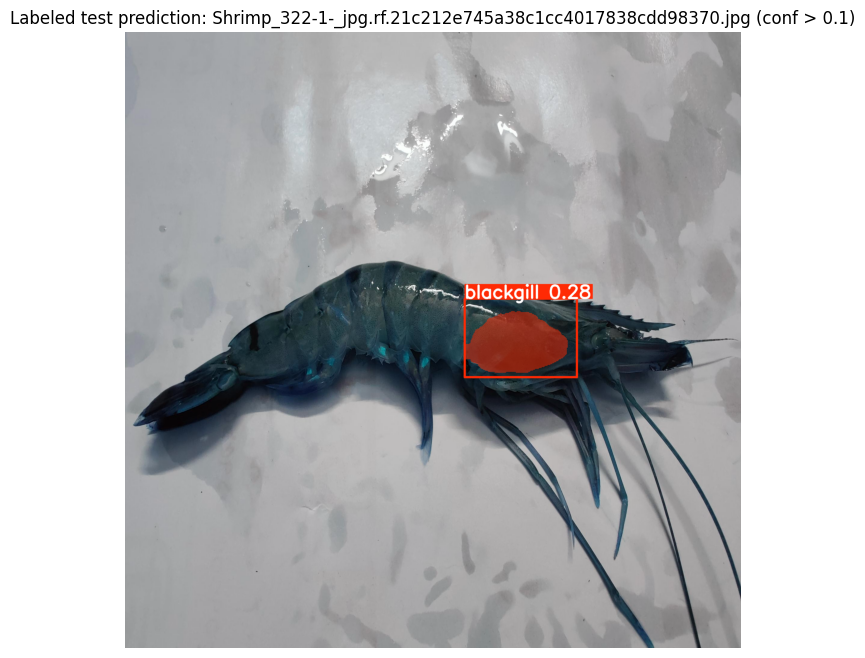

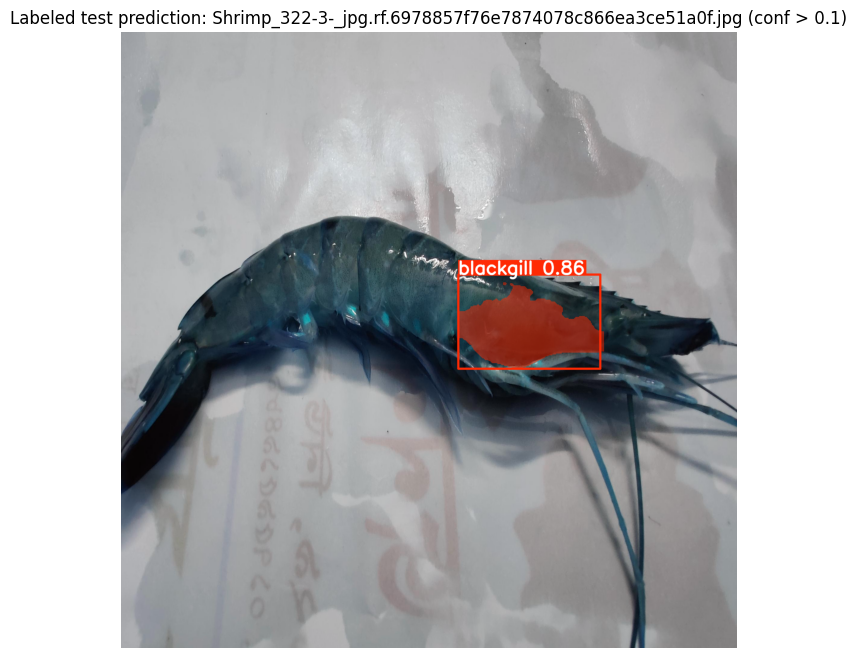

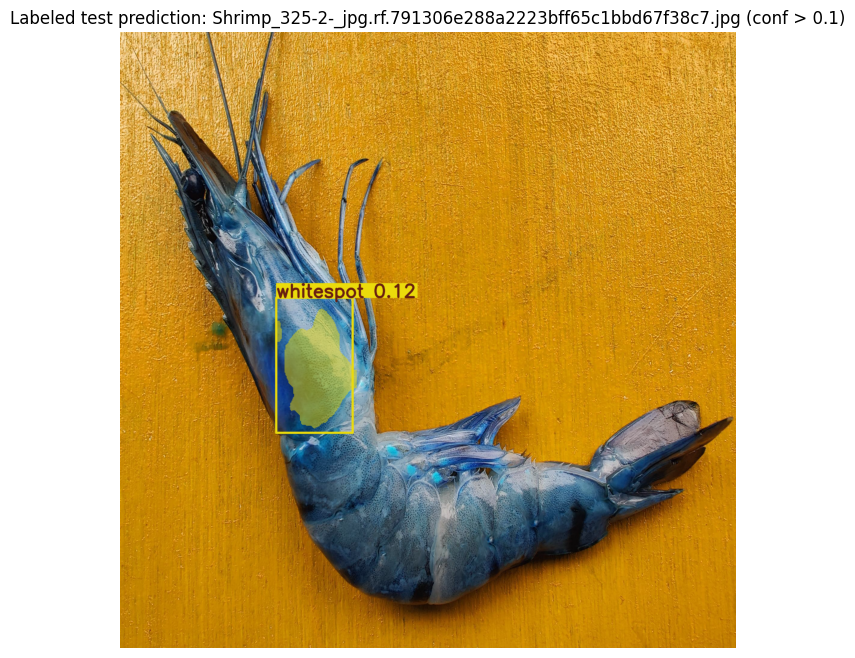

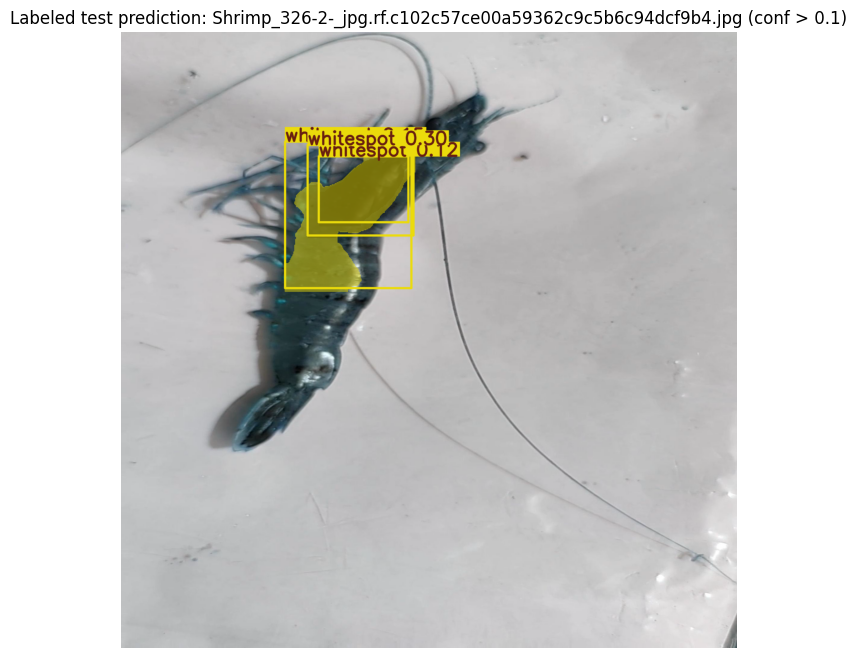

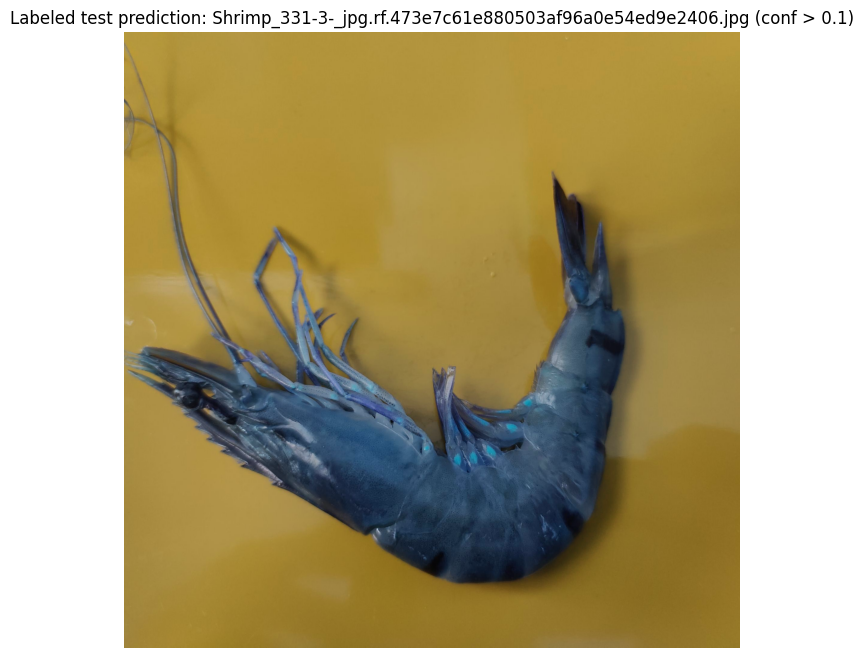

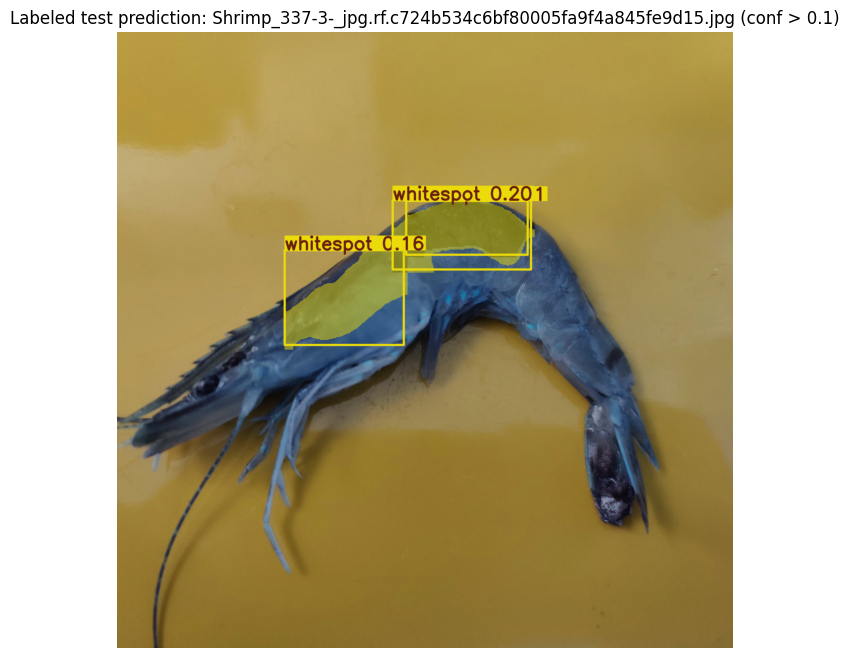

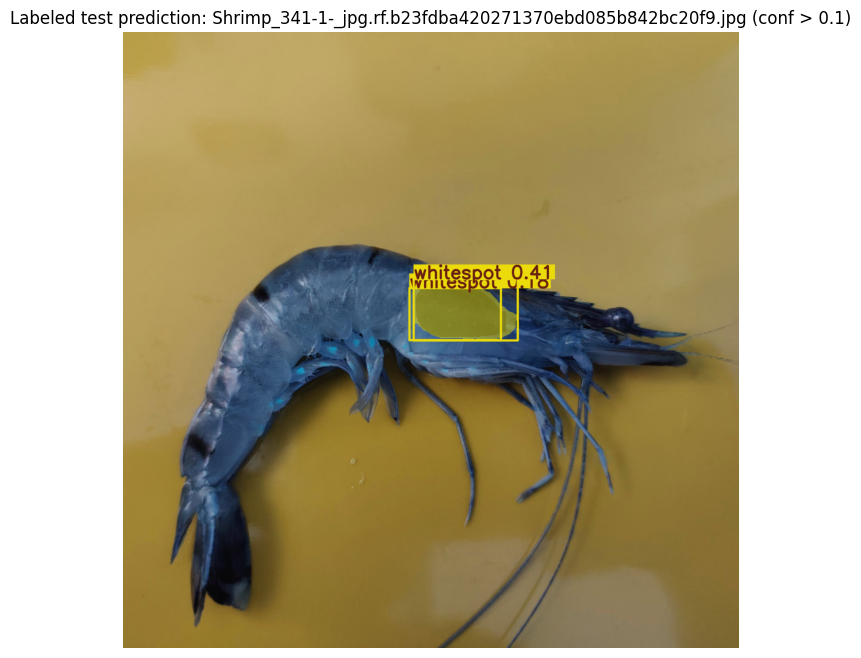

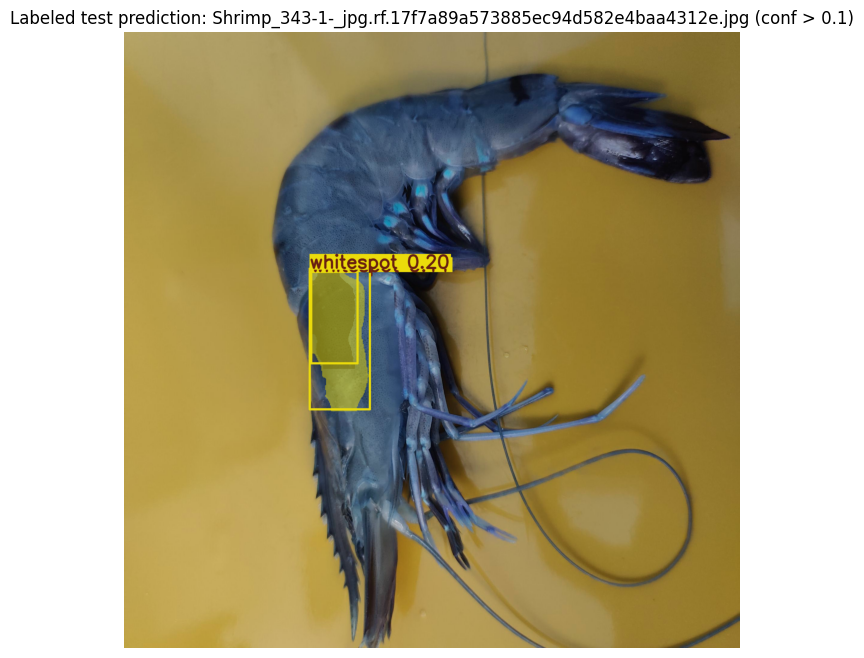

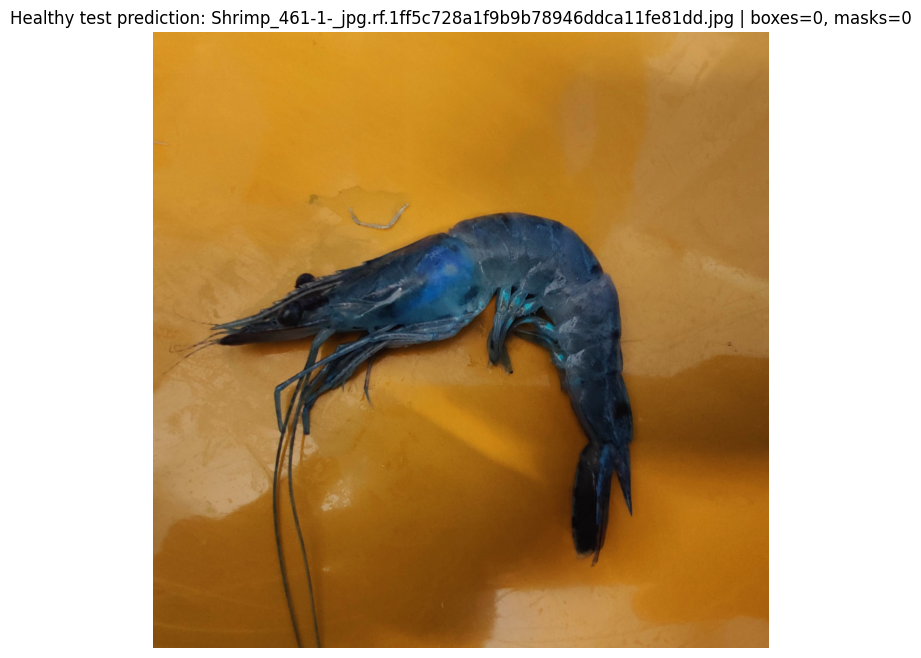

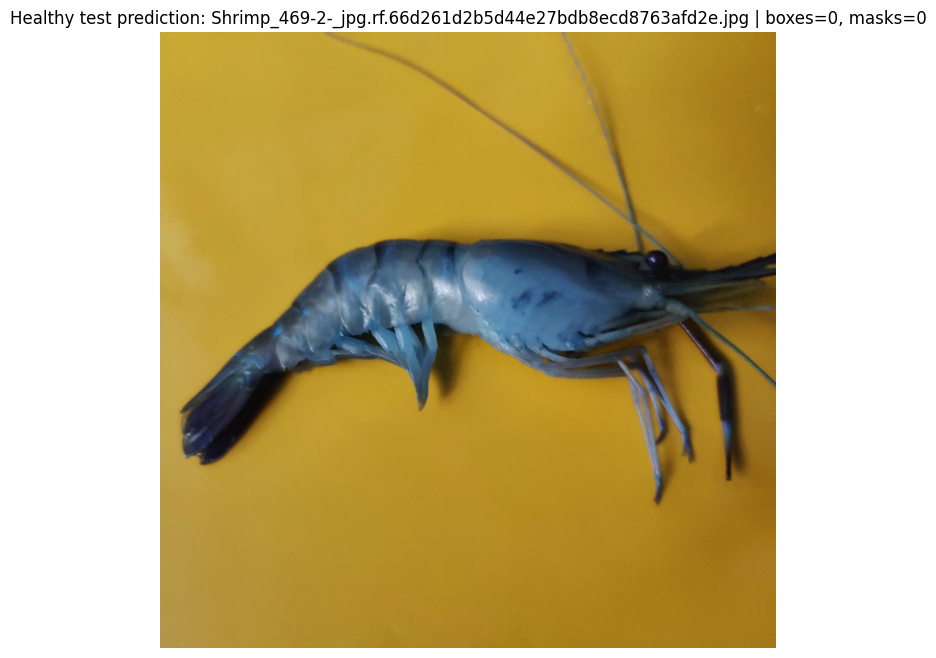

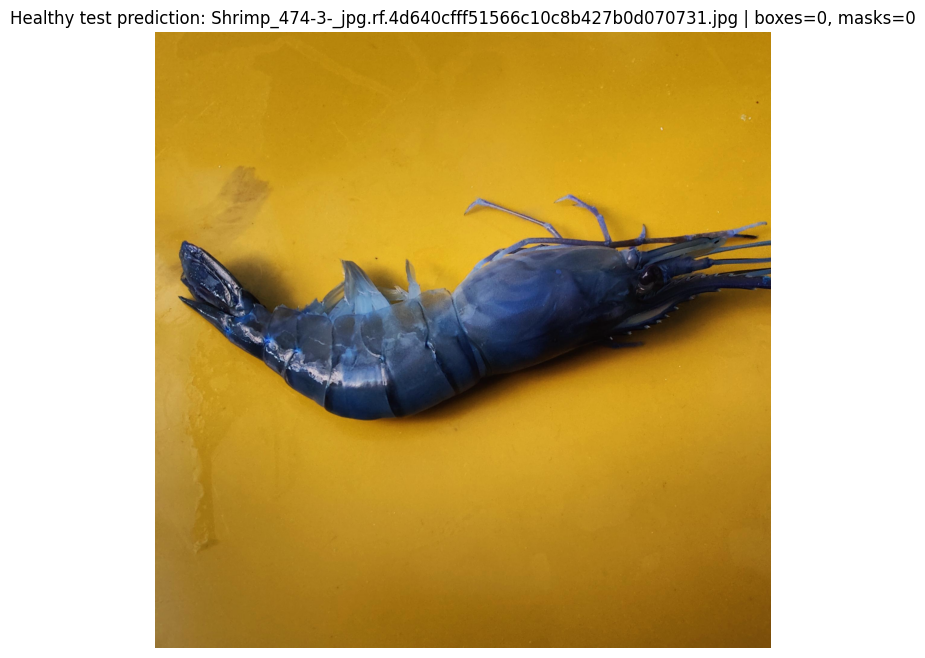

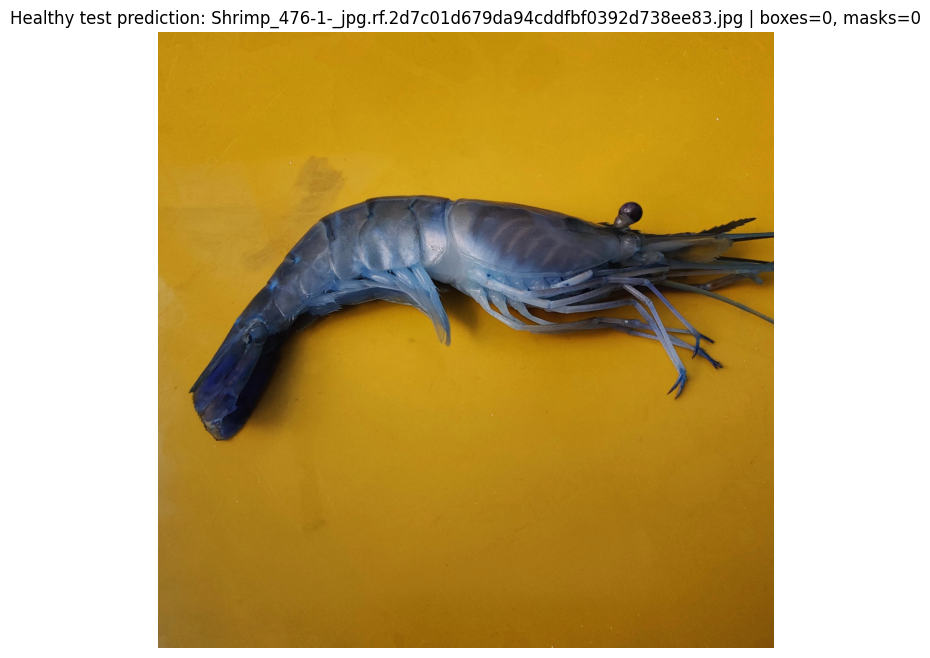

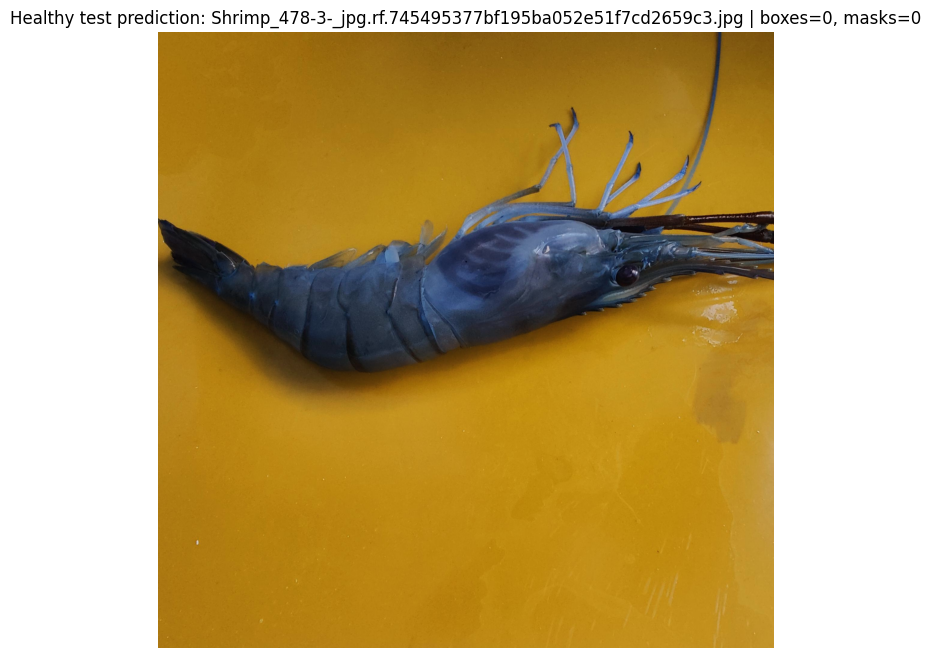

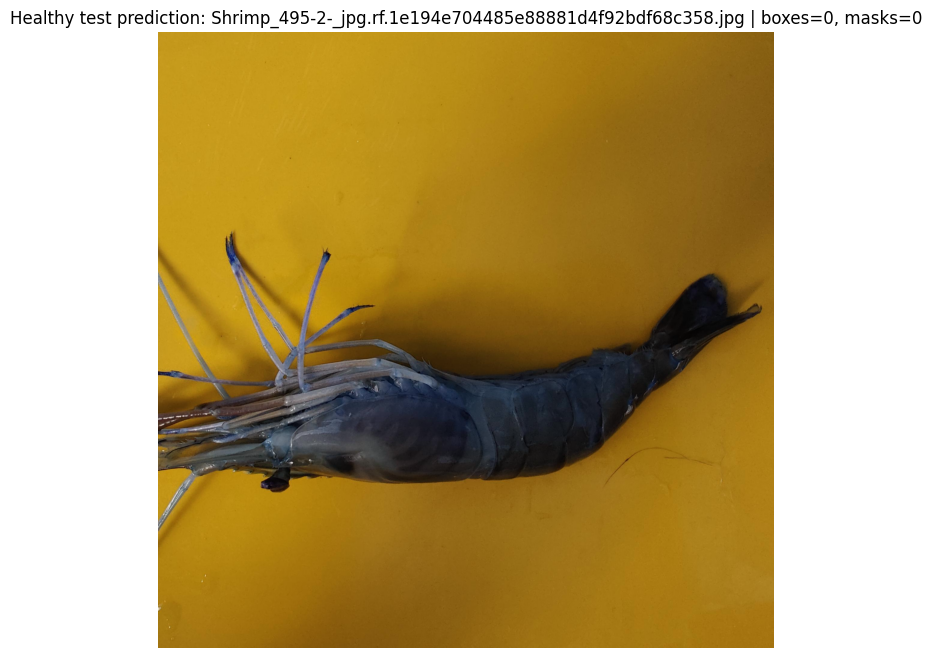

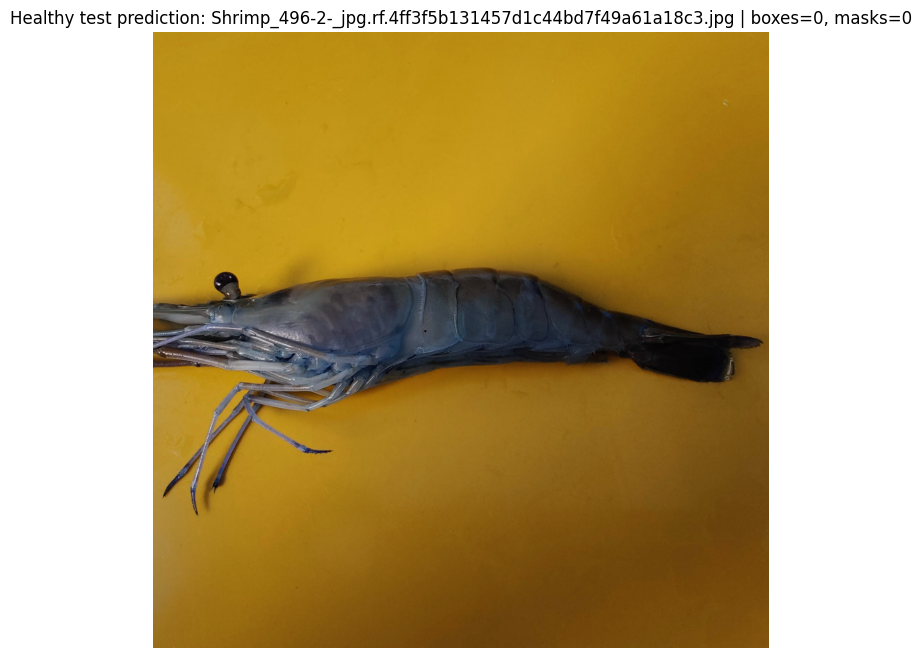

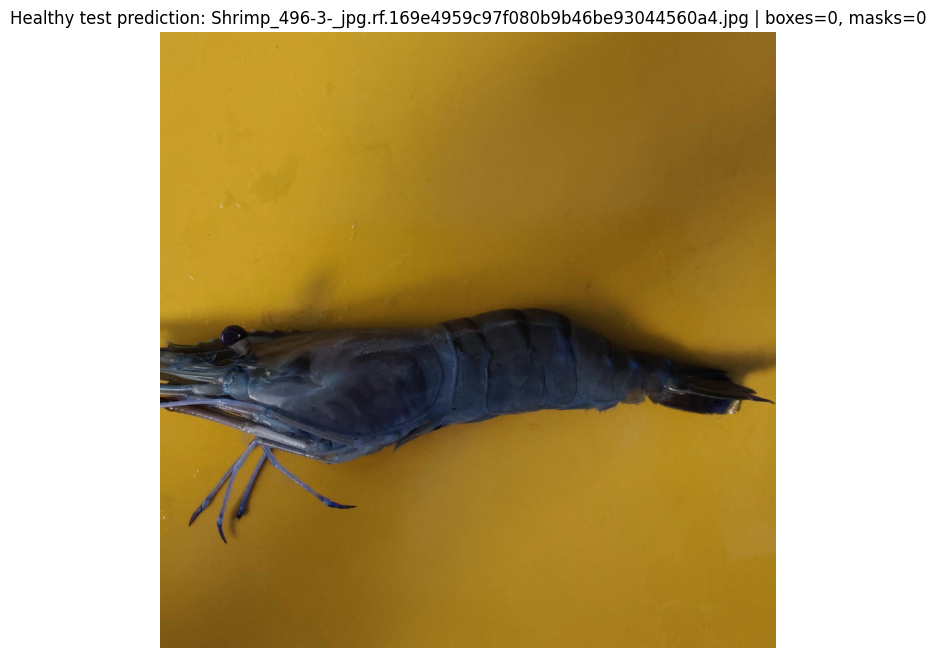

In [12]:
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import yaml

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

COUNT_PENALTY_WEIGHT = 0.02
DISEASE_MISS_PENALTY_WEIGHT = 0.50
HEALTHY_FP_PENALTY_WEIGHT = 0.50


def metric_value(metrics, dotted_name, default=0.0):
    value = metrics
    try:
        for part in dotted_name.split('.'):
            value = getattr(value, part)
        return float(value)
    except Exception:
        return default


def healthy_false_positive_summary(model, image_dir, conf=0.25):
    image_dir = Path(image_dir)
    images = []
    for ext in IMAGE_EXTENSIONS:
        images.extend(image_dir.glob(f'*{ext}'))
    images = sorted(images)

    if not images:
        return {
            'healthy_image_count': 0,
            'healthy_mask_fp_rate': 0.0,
            'healthy_box_fp_rate': 0.0,
            'healthy_fp_masks_per_image': 0.0,
            'healthy_fp_boxes_per_image': 0.0,
        }

    results = model.predict(source=[str(p) for p in images], conf=conf, save=False, verbose=False)
    fp_mask_images = 0
    fp_box_images = 0
    total_masks = 0
    total_boxes = 0

    for result in results:
        mask_count = len(result.masks) if result.masks is not None else 0
        box_count = len(result.boxes) if result.boxes is not None else 0
        total_masks += mask_count
        total_boxes += box_count
        fp_mask_images += int(mask_count > 0)
        fp_box_images += int(box_count > 0)

    n = len(images)
    return {
        'healthy_image_count': n,
        'healthy_mask_fp_rate': fp_mask_images / n,
        'healthy_box_fp_rate': fp_box_images / n,
        'healthy_fp_masks_per_image': total_masks / n,
        'healthy_fp_boxes_per_image': total_boxes / n,
    }


def has_nonempty_label(label_path):
    return Path(label_path).exists() and bool(Path(label_path).read_text().strip())


def copy_eval_subset(source_dataset_dir, target_dataset_dir, keep_labeled):
    source_dataset_dir = Path(source_dataset_dir)
    target_dataset_dir = Path(target_dataset_dir)
    image_out = target_dataset_dir / 'test' / 'images'
    label_out = target_dataset_dir / 'test' / 'labels'
    image_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    copied = 0
    source_image_dir = source_dataset_dir / 'test' / 'images'
    source_label_dir = source_dataset_dir / 'test' / 'labels'

    for ext in IMAGE_EXTENSIONS:
        for image_path in source_image_dir.glob(f'*{ext}'):
            label_path = source_label_dir / f'{image_path.stem}.txt'
            labeled = has_nonempty_label(label_path)
            if labeled != keep_labeled:
                continue

            shutil.copy2(image_path, image_out / image_path.name)
            if label_path.exists():
                shutil.copy2(label_path, label_out / label_path.name)
            else:
                (label_out / f'{image_path.stem}.txt').write_text('')
            copied += 1

    return copied


def write_eval_yaml(source_yaml, target_yaml, target_dataset_dir):
    source_yaml = Path(source_yaml)
    target_yaml = Path(target_yaml)
    target_dataset_dir = Path(target_dataset_dir)
    with open(source_yaml, 'r') as f:
        cfg = yaml.safe_load(f)

    cfg['train'] = str(target_dataset_dir / 'test' / 'images')
    cfg['val'] = str(target_dataset_dir / 'test' / 'images')
    cfg['test'] = str(target_dataset_dir / 'test' / 'images')

    target_yaml.parent.mkdir(parents=True, exist_ok=True)
    with open(target_yaml, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return cfg


model_inference = YOLO(str(best_model_path))
selected_exp = BEST_RUN['experiment'] if 'BEST_RUN' in globals() else run_path.name
selected_dataset_dir = EXPERIMENT_ROOT / selected_exp / 'dataset' if 'EXPERIMENT_ROOT' in globals() and 'BEST_RUN' in globals() else Path('/content/ewu_shrimp_disease-1')
selected_yaml = selected_dataset_dir / 'data.yaml'
selected_labeled_dir = REPORT_DIR / 'dataset_labeled_only_eval'
selected_labeled_yaml = selected_labeled_dir / 'data_labeled_only.yaml'
selected_healthy_dir = REPORT_DIR / 'dataset_healthy_only_eval'
selected_healthy_yaml = selected_healthy_dir / 'data_healthy_only.yaml'

labeled_count = copy_eval_subset(selected_dataset_dir, selected_labeled_dir, keep_labeled=True)
healthy_count = copy_eval_subset(selected_dataset_dir, selected_healthy_dir, keep_labeled=False)
labeled_cfg = write_eval_yaml(selected_yaml, selected_labeled_yaml, selected_labeled_dir)
healthy_cfg = write_eval_yaml(selected_yaml, selected_healthy_yaml, selected_healthy_dir)
class_names = labeled_cfg.get('names', [])

print('Selected experiment:', selected_exp)
print('Selected dataset dir:', selected_dataset_dir)
print('Labeled-only test images:', labeled_count)
print('Healthy-only test images:', healthy_count)

print('Full test-set evaluation:')
full_test_metrics = model_inference.val(data=str(selected_yaml), split='test', imgsz=640, plots=True, verbose=False)
print('Labeled-only diseased test-set evaluation:')
labeled_test_metrics = model_inference.val(data=str(selected_labeled_yaml), split='test', imgsz=640, plots=False, verbose=False)
healthy_test_fp = healthy_false_positive_summary(model_inference, selected_healthy_dir / 'test' / 'images')

print('Full test mask mAP50:', metric_value(full_test_metrics, 'seg.map50'))
print('Labeled-only diseased test mask mAP50:', metric_value(labeled_test_metrics, 'seg.map50'))
print('Healthy test mask false-positive rate:', healthy_test_fp['healthy_mask_fp_rate'])
print('Healthy test false-positive masks per image:', healthy_test_fp['healthy_fp_masks_per_image'])


def draw_yolo_segmentation_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    overlay = image.copy()
    colors = [(255, 70, 70), (70, 180, 255), (90, 220, 120), (240, 180, 60)]

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            cls_id = int(float(parts[0]))
            coords = np.array([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= width
            coords[:, 1] *= height
            pts = coords.astype(np.int32)
            color = colors[cls_id % len(colors)]
            cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=2)
            cv2.fillPoly(overlay, [pts], color=color)
            x, y = pts[0]
            label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            cv2.putText(overlay, label, (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return cv2.addWeighted(overlay, 0.35, image, 0.65, 0)


# Visualize augmented training ground-truth masks directly.
aug_images = sorted((selected_dataset_dir / 'train' / 'images').glob('aug_*'))
random.seed(42)
aug_images = random.sample(aug_images, k=min(6, len(aug_images)))

if aug_images:
    fig, axes = plt.subplots(len(aug_images), 1, figsize=(10, 5 * len(aug_images)))
    if len(aug_images) == 1:
        axes = [axes]
    for ax, image_path in zip(axes, aug_images):
        label_path = selected_dataset_dir / 'train' / 'labels' / f'{image_path.stem}.txt'
        ax.imshow(draw_yolo_segmentation_labels(image_path, label_path))
        ax.set_title(f'Augmented train GT mask: {image_path.name} | label exists={label_path.exists()}')
        ax.axis('off')
    plt.show()
else:
    print('No augmented training images found to visualize.')

# Visualize labeled test predictions.
test_images = []
for ext in IMAGE_EXTENSIONS:
    test_images.extend((selected_dataset_dir / 'test' / 'images').glob(f'*{ext}'))

def has_nonempty_test_label(image_path):
    label_path = selected_dataset_dir / 'test' / 'labels' / f'{image_path.stem}.txt'
    return label_path.exists() and bool(label_path.read_text().strip())

test_images = [p for p in sorted(test_images) if has_nonempty_test_label(p)]
test_images = test_images[:8]

results = model_inference.predict(source=[str(p) for p in test_images], conf=0.1, save=True, verbose=False)
for image_path, result in zip(test_images, results):
    plt.figure(figsize=(8, 8))
    plt.imshow(result.plot())
    plt.title(f'Labeled test prediction: {image_path.name} (conf > 0.1)')
    plt.axis('off')
    plt.show()

# Visualize healthy negative predictions to inspect false positives.
healthy_images = []
for ext in IMAGE_EXTENSIONS:
    healthy_images.extend((selected_healthy_dir / 'test' / 'images').glob(f'*{ext}'))
healthy_images = sorted(healthy_images)[:8]

if healthy_images:
    healthy_results = model_inference.predict(source=[str(p) for p in healthy_images], conf=0.1, save=False, verbose=False)
    for image_path, result in zip(healthy_images, healthy_results):
        plt.figure(figsize=(8, 8))
        plt.imshow(result.plot())
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        plt.title(f'Healthy test prediction: {image_path.name} | boxes={box_count}, masks={mask_count}')
        plt.axis('off')
        plt.show()
else:
    print('No healthy test images found to visualize.')


**Missed Box Metric**


In [1]:
from collections import Counter
from pathlib import Path
from PIL import Image
import torch
import yaml

MISS_SPLIT = "val"  # Change to "test" if needed.
MISS_IOU_THRESHOLD = 0.50
MISS_CONF_THRESHOLD = 0.25
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def class_name(names, class_id):
    if isinstance(names, dict):
        return names.get(class_id, names.get(str(class_id), str(class_id)))
    if isinstance(names, list) and class_id < len(names):
        return names[class_id]
    return str(class_id)


def image_label_path(image_path):
    image_path = Path(image_path)
    if image_path.parent.name == "images":
        return image_path.parent.parent / "labels" / f"{image_path.stem}.txt"
    return image_path.with_suffix(".txt")


def read_yolo_seg_boxes(label_path, image_path):
    if not Path(label_path).exists():
        return []

    width, height = Image.open(image_path).size
    boxes = []
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        vals = [float(x) for x in parts[1:]]

        if len(vals) == 4:
            x, y, w, h = vals
            x1 = (x - w / 2) * width
            y1 = (y - h / 2) * height
            x2 = (x + w / 2) * width
            y2 = (y + h / 2) * height
        else:
            xs = vals[0::2]
            ys = vals[1::2]
            x1 = min(xs) * width
            y1 = min(ys) * height
            x2 = max(xs) * width
            y2 = max(ys) * height

        boxes.append({"cls": cls, "box": torch.tensor([x1, y1, x2, y2], dtype=torch.float32)})
    return boxes


def box_iou(box, boxes):
    if boxes.numel() == 0:
        return torch.empty(0)

    x1 = torch.maximum(box[0], boxes[:, 0])
    y1 = torch.maximum(box[1], boxes[:, 1])
    x2 = torch.minimum(box[2], boxes[:, 2])
    y2 = torch.minimum(box[3], boxes[:, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (box[2] - box[0]).clamp(min=0) * (box[3] - box[1]).clamp(min=0)
    area2 = (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (boxes[:, 3] - boxes[:, 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + 1e-9)


with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

split_source = Path(data_cfg.get(MISS_SPLIT, ""))
if not split_source.is_absolute():
    split_source = Path(DATA_YAML).parent / split_source

image_paths = sorted(p for p in split_source.rglob("*") if p.suffix.lower() in IMAGE_EXTS)

pred_results = best_model.predict(
    source=[str(p) for p in image_paths],
    imgsz=640,
    conf=MISS_CONF_THRESHOLD,
    iou=0.5,
    device=0,
    save=False,
    verbose=False,
)

gt_by_class = Counter()
missed_by_class = Counter()
total_gt = 0
total_missed = 0

for image_path, result in zip(image_paths, pred_results):
    gt_items = read_yolo_seg_boxes(image_label_path(image_path), image_path)
    total_gt += len(gt_items)

    if result.boxes is None or len(result.boxes) == 0:
        pred_boxes = torch.empty((0, 4), dtype=torch.float32)
        pred_classes = torch.empty((0,), dtype=torch.long)
    else:
        pred_boxes = result.boxes.xyxy.detach().cpu().float()
        pred_classes = result.boxes.cls.detach().cpu().long()

    matched_pred = set()
    for gt in gt_items:
        gt_cls = gt["cls"]
        gt_by_class[gt_cls] += 1
        candidates = [
            i for i, pred_cls in enumerate(pred_classes.tolist())
            if pred_cls == gt_cls and i not in matched_pred
        ]

        matched = False
        if candidates:
            candidate_boxes = pred_boxes[candidates]
            ious = box_iou(gt["box"], candidate_boxes)
            best_iou, best_local_idx = torch.max(ious, dim=0)
            if float(best_iou) >= MISS_IOU_THRESHOLD:
                matched_pred.add(candidates[int(best_local_idx)])
                matched = True

        if not matched:
            missed_by_class[gt_cls] += 1
            total_missed += 1

detected_gt = total_gt - total_missed

print("Missed-box split:", MISS_SPLIT)
print("Total GT boxes:", total_gt)
print("Detected GT boxes:", detected_gt)
print("Missed GT boxes:", total_missed)
print("Missed-box rate:", total_missed / total_gt if total_gt else 0.0)
print("Box recall by count:", detected_gt / total_gt if total_gt else 0.0)

print("\nMissed boxes by class:")
for cls_id in sorted(gt_by_class):
    gt_count = gt_by_class[cls_id]
    missed_count = missed_by_class[cls_id]
    print(
        f"  {class_name(data_cfg.get('names', best_model.names), cls_id)}: "
        f"missed {missed_count}/{gt_count} "
        f"({missed_count / gt_count if gt_count else 0.0:.4f})"
    )


NameError: name 'DATA_YAML' is not defined

**Visualize Predictions**


In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

predict_dir = Path("/content/runs/predict_shrimp_eca/eca_predict")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
images = sorted([p for p in predict_dir.rglob("*") if p.suffix.lower() in image_exts]) if predict_dir.exists() else []

if not images:
    print(f"No prediction images found in {predict_dir}")
else:
    show_images = images[:8]
    cols = min(4, len(show_images))
    rows = (len(show_images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = [axes] if len(show_images) == 1 else axes.flatten()

    for ax, img_path in zip(axes, show_images):
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.name)
        ax.axis("off")

    for ax in axes[len(show_images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
